<a href="https://colab.research.google.com/github/nikamade/Data201/blob/main/Week5_Assignment_Iris_Resampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DATA 201 --- Week 5 Assignment**

## **Resampling Methods with the Iris Dataset**

In this assignment, we will explore **bootstrap resampling, jackknife resampling, and permutation tests** using the **Iris dataset.**

The Iris dataset contains measurements of iris flowers from three species:

Setosa
Versicolor
Virginica
Each flower has four measurements:

sepal length
sepal width
petal length
petal width

---------------------------------------
## **Load the Dataset**
Use the following code to load the dataset.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

iris = sns.load_dataset("iris")

iris.head()

## **Tasks**

Print the number of observations in the dataset.
Print the column names.
Count how many observations exist for each species.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

iris = sns.load_dataset("iris")
iris.head()
# number of observation
print("Number of observations:", len(iris))
#column names
print("Column names:", iris.columns.tolist())
# count each species
print("Observations per species:\n", iris['species'].value_counts())

Number of observations: 150
Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Observations per species:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## **Part 1 --- Bootstrap Resampling**

We will estimate the mean sepal length using bootstrap resampling.

# **Task 1 --- Basic Statistics**

Compute the following statistics for sepal length:

* mean
* median
* standard deviation

In [2]:
import numpy as np
sepal = iris['sepal_length']  # this is the sample

print("Mean:", np.mean(sepal))
print("Median:", np.median(sepal))
print("Std:", np.std(sepal))

Mean: 5.843333333333334
Median: 5.8
Std: 0.8253012917851409


## **Task 2 --- Bootstrap the Mean**

Perform **5,000 bootstrap resamples.**

Procedure:

1.Sample the dataset **with replacement.**

2.Each sample must contain **150 observations.**

3.Compute the **mean sepal length** for each resample.

Store the results.

Plot the **distribution of bootstrap means.**

**Note on Efficiency**

While 5,000 iterations is manageable for 150 rows, consider the computational cost if our dataset had 1 million rows. If your computer feels slow, try 1,000 iterations first.

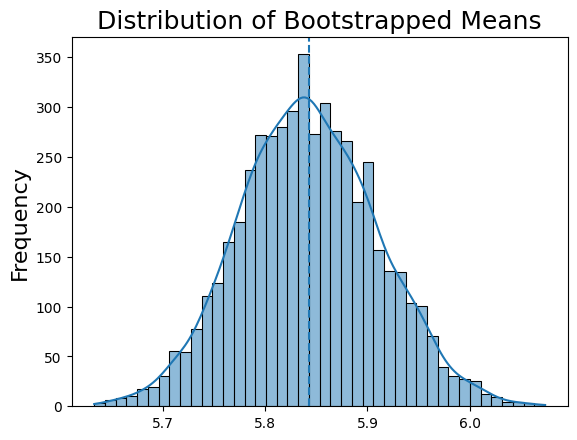

Bootstrapped Mean: 5.84


In [3]:
n_bootstrap = 5000
bootstrap_means = []

# Boucle Bootstrap pour la moyenne
for b in range(n_bootstrap):
    boot_sample = np.random.choice(sepal, size=len(sepal), replace=True)  # Tirage avec remise
    bootstrap_means.append(np.mean(boot_sample))  # Calcul de la moyenne

# Convertir en array
bootstrap_means = np.array(bootstrap_means)

# Plot de la distribution des moyennes bootstrap
sns.histplot(bootstrap_means, kde=True, label='Bootstrap')
plt.axvline(x=np.mean(bootstrap_means), ymin=0, ymax=1, linestyle='--')  # Ligne à la moyenne
plt.title('Distribution of Bootstrapped Means', fontsize=18)
plt.ylabel('Frequency', fontsize=16)
plt.show()

# Afficher la moyenne bootstrap
print(f'Bootstrapped Mean: {np.mean(bootstrap_means):.3}')

## **Task 3 --- Confidence Interval**

Using the bootstrap results, compute the **95% confidence interval** using the percentile method:

CI = [2.5%, 97.5%]

Report:

* Bootstrap mean
* Lower bound
* Upper bound

**Question**
Why is it mathematically necessary to sample **with replacement** in bootstrap resampling?

In [4]:
lower = np.percentile(bootstrap_means, 2.5)
upper = np.percentile(bootstrap_means, 97.5)
mean_boot = np.mean(bootstrap_means)

print("Bootstrap Mean:", mean_boot)
print("95% CI:", (lower, upper))

Bootstrap Mean: 5.842680400000001
95% CI: (np.float64(5.712666666666667), np.float64(5.977333333333333))


# **Part 2 --- Jackknife Resampling**

## **Task 4 --- Jackknife the Mean**
Create jackknife samples by removing **one observation at a time.**

Steps:

For each observation i, remove it from the dataset.
Compute the mean of the remaining observations.
Store the result.
Plot **the distribution of jackknife means.**

**Visualization Tip**

Because you are removing only **one data point at a time**, the resulting means will be extremely similar. You may need to:

* use a large number of bins, or
* adjust plt.xlim()
to clearly see the variation.

Question
If the dataset contains n observations, exactly how many jackknife samples are created? // **ANSWER** n

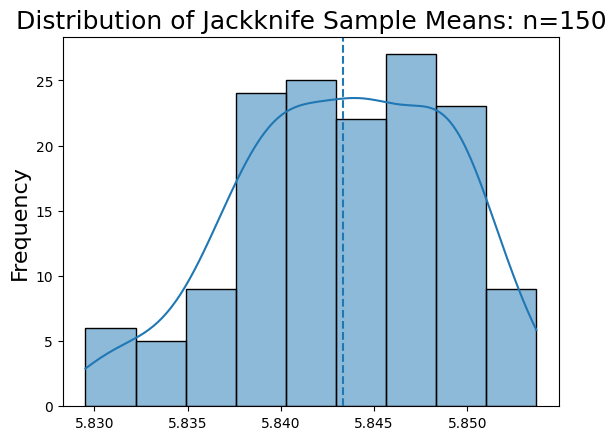

Number of Jackknife samples: 150
Jackknife Mean: 5.843333333333334


In [5]:
def jackknife_resampling(sepal):
    n = len(sepal)
    jackknife_means = np.zeros(n)

    # Romoved one observation and calcolate the Mean
    for i in range(n):
        jackknife_sample = np.delete(sepal, i)
        jackknife_means[i] = np.mean(jackknife_sample)

    return jackknife_means

jackknife_means = jackknife_resampling(sepal)

# Plot distribution

sns.histplot(jackknife_means, kde=True, label='Means of Jackknife Samples')
plt.axvline(x=np.mean(jackknife_means), ymin=0, ymax=1, linestyle='--')
plt.title(f'Distribution of Jackknife Sample Means: n={len(sepal)}', fontsize=18)
plt.ylabel('Frequency', fontsize=16)
plt.show()

# Nombre de Jackknife samples
print("Number of Jackknife samples:", len(jackknife_means))
print("Jackknife Mean:", np.mean(jackknife_means))

# **Part 3 --- Permutation Test**

We will test whether sepal length differs significantly between two species.

For this task, use:

* Versicolor
* Virginica


In [6]:
versicolor = iris[iris['species'] == 'versicolor']['sepal_length'].values
virginica  = iris[iris['species'] == 'virginica']['sepal_length'].values


## **Task 5 --- Observed Statistic**

Compute the observed difference in means:

difference = mean(Versicolor) − mean(Virginica)

In [7]:
observed_diff = np.mean(versicolor) - np.mean(virginica)
print(f"Observed Difference: {observed_diff:.3f}")

Observed Difference: -0.652


## **Task 6 --- Permutation Simulation**
Run **1,000 permutations.**

Procedure:

1.Combine the two species into one dataset.

2.**Shuffle (permute) the labels.**

3.Split the data back into two groups of the original sizes.

4.Compute the difference in means.
Store the result.

5.Plot the permutation distribution.

Observed difference: -0.652
Lower: -0.2159999999999993
Upper: 0.20800000000000024


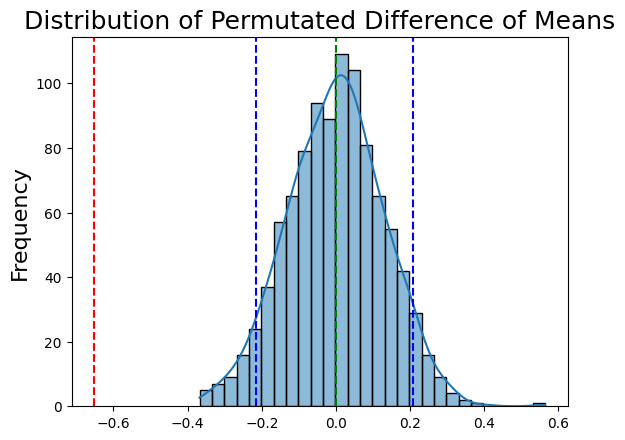

In [8]:
simu_diff = []
n_samples = 1000
n_versicolor = len(versicolor)

all_sepal = np.concatenate([versicolor, virginica])

for i in range(n_samples):
    perm_sample = np.random.permutation(all_sepal)
    perm_versicolor = perm_sample[:n_versicolor]
    perm_virginica  = perm_sample[n_versicolor:]
    perm_diff = np.mean(perm_versicolor) - np.mean(perm_virginica)
    simu_diff.append(perm_diff)

simu_diff = np.array(simu_diff)

observed_diff = np.mean(versicolor) - np.mean(virginica)

# Intervalle
lower = np.quantile(simu_diff, 0.05)
upper = np.quantile(simu_diff, 0.95)

print("Observed difference:", round(observed_diff, 3))
print("Lower:", lower)
print("Upper:", upper)

# Plot
sns.histplot(simu_diff, kde=True, label='Permutation')

plt.axvline(x=np.mean(simu_diff), ymin=0, ymax=1, color='green', linestyle='--')
plt.axvline(x=observed_diff, ymin=0, ymax=1, color='red', linestyle='--')
plt.axvline(x=lower, ymin=0, ymax=1, color='blue', linestyle='--')
plt.axvline(x=upper, ymin=0, ymax=1, color='blue', linestyle='--')

plt.title('Distribution of Permutated Difference of Means', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

plt.show()

## **Task 7 --- p-value**
Compute the p-value:

p = (number of simulated differences ≥ observed difference) / (total simulations)

Interpret the result at α = 0.05.



In [9]:
# p-value
p_value = np.sum(np.abs(simu_diff) >= np.abs(observed_diff)) / n_samples
print(f"P-value: {p_value:.3f}")

P-value: 0.000


**Questions**

What is the null hypothesis (H0) in this specific test? **ANSWER** there is no difference in the mean petal length between the Iris species.
What does the permutation distribution represent in terms of random chance? // **ANSWER** it show could happen if every is done ramdomly
Based on your p-value, do you reject or fail to reject the null hypothesis? // **ANSWER**  the p-value is 0.000 and is less than the significance level (0.05), we reject the null hypothesis. Therefore, there is a statistically significant difference in the mean petal length between the Iris species.
